# Exploratory Data Analysis (EDA)
## Project: Product Placement Optimisation
### Purpose: Visualize patterns in clean data before running ML algorithms
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project
### Input: data/processed/sales_data_cleaned.csv
### Output: 8 charts saved to reports/figures/

## Charts Planned

1. Top 20 products by sales count
2. Category distribution
3. Top 20 products by revenue
4. Basket value distribution (shows our baseline KPI)
5. Items per basket distribution
6. Categories per basket
7. Category co-occurrence heatmap (KEY chart for placement)
8. Top product pairs bought together

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

print("Libraries loaded!")
print(f"Figures will be saved to: {figures_path}")

Libraries loaded!
Figures will be saved to: D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures


## Load Cleaned Data

In [7]:
df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Categories: {df['category'].nunique()}")
print(f"Invoices: {df['invoice_no'].nunique():,}")

Data loaded successfully!
Shape: (767180, 14)
Categories: 25
Invoices: 218,037


## Chart 1: Top 20 Products by Sales Count

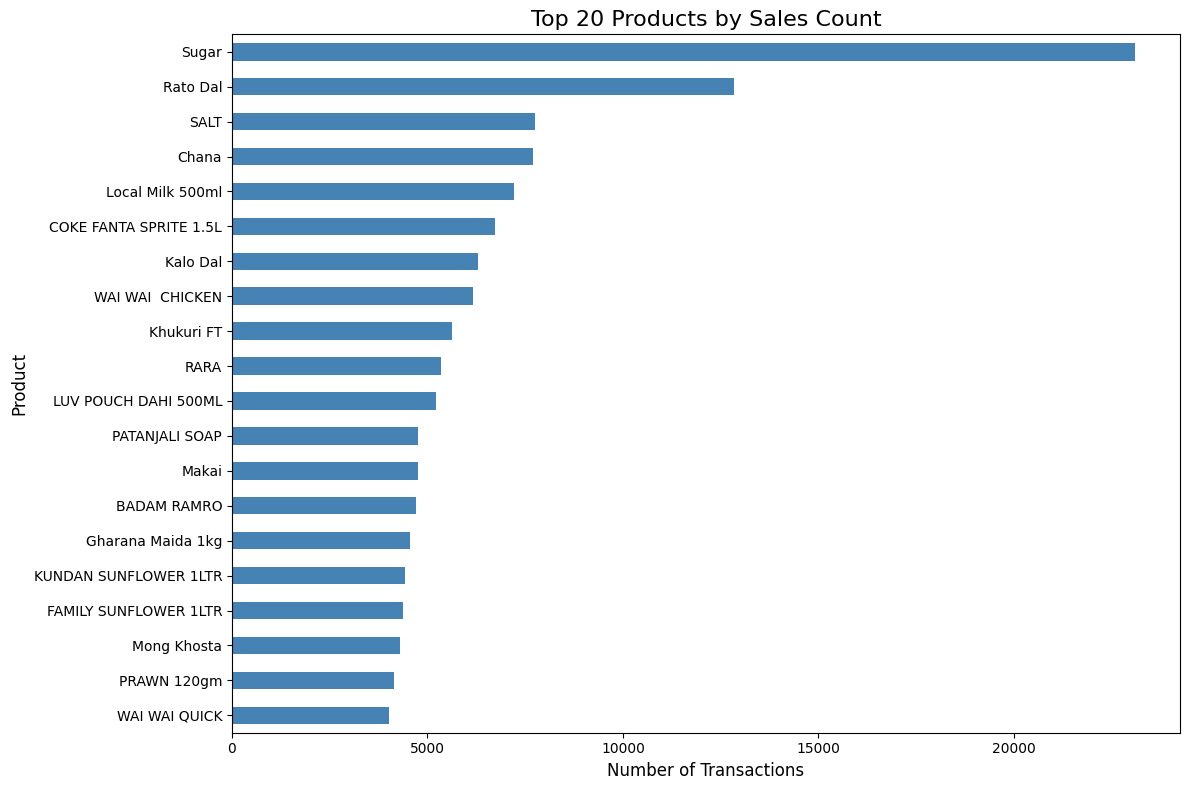

Chart 1 saved!


In [8]:
top_products = df['product'].value_counts().head(20)

plt.figure(figsize=(12, 8))
top_products.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Products by Sales Count', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart1_top20_products_count.png'), dpi=150)
plt.show()
print("Chart 1 saved!")

## Chart 2: Category Distribution

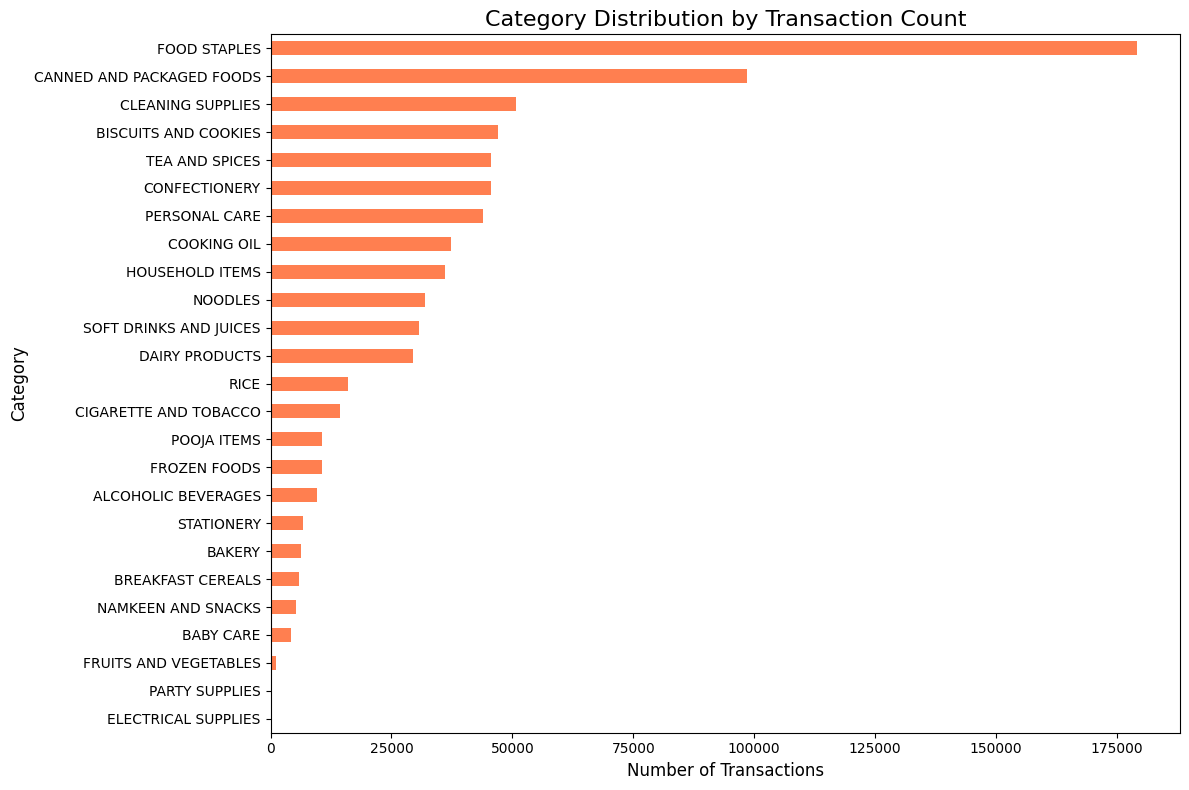

Chart 2 saved!


In [9]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(12, 8))
category_counts.sort_values().plot(kind='barh', color='coral')
plt.title('Category Distribution by Transaction Count', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart2_category_distribution.png'), dpi=150)
plt.show()
print("Chart 2 saved!")

## Chart 3: Top 20 Products by Revenue

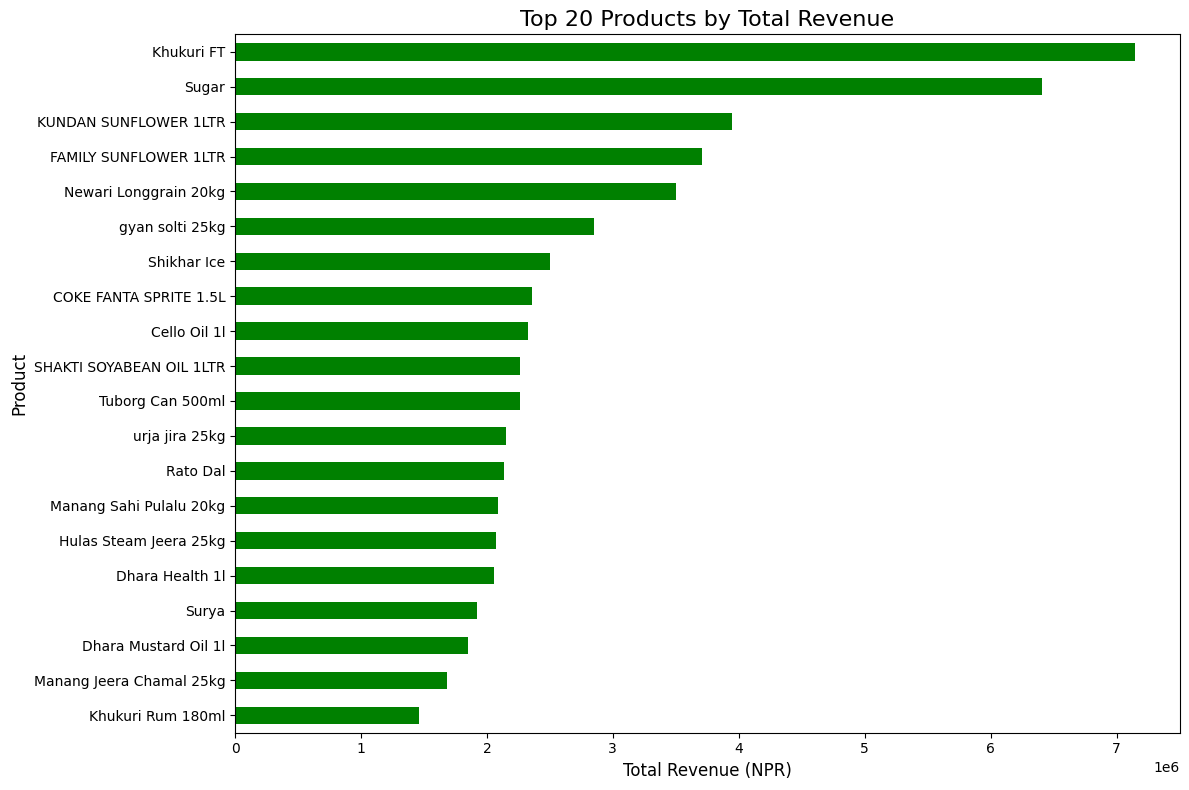

Chart 3 saved!


In [10]:
top_revenue = df.groupby('product')['total_amount'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
top_revenue.sort_values().plot(kind='barh', color='green')
plt.title('Top 20 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue (NPR)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart3_top20_products_revenue.png'), dpi=150)
plt.show()
print("Chart 3 saved!")

## Chart 4: Basket Value Distribution

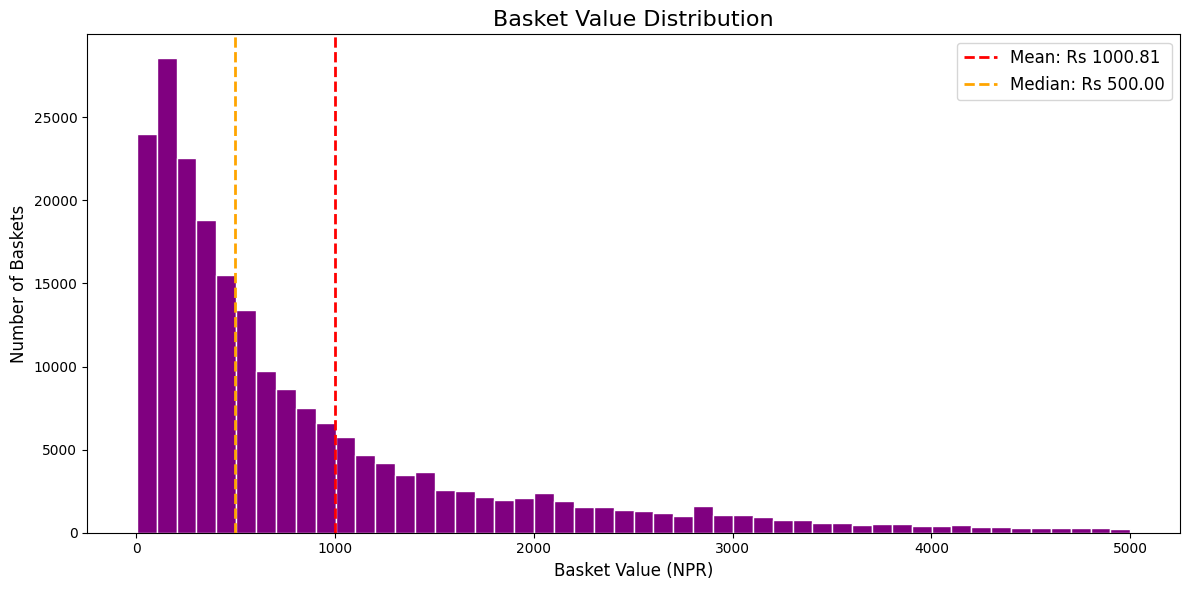

Chart 4 saved!
Mean basket value: Rs 1000.81
Median basket value: Rs 500.00


In [11]:
basket_values = df.groupby('invoice_no')['total_amount'].sum()

plt.figure(figsize=(12, 6))
plt.hist(basket_values[basket_values <= 5000], bins=50, color='purple', edgecolor='white')
plt.axvline(basket_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: Rs {basket_values.mean():.2f}')
plt.axvline(basket_values.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: Rs {basket_values.median():.2f}')
plt.title('Basket Value Distribution', fontsize=16)
plt.xlabel('Basket Value (NPR)', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart4_basket_value_distribution.png'), dpi=150)
plt.show()
print(f"Chart 4 saved!")
print(f"Mean basket value: Rs {basket_values.mean():.2f}")
print(f"Median basket value: Rs {basket_values.median():.2f}")

## Chart 5: Items Per Basket Distribution

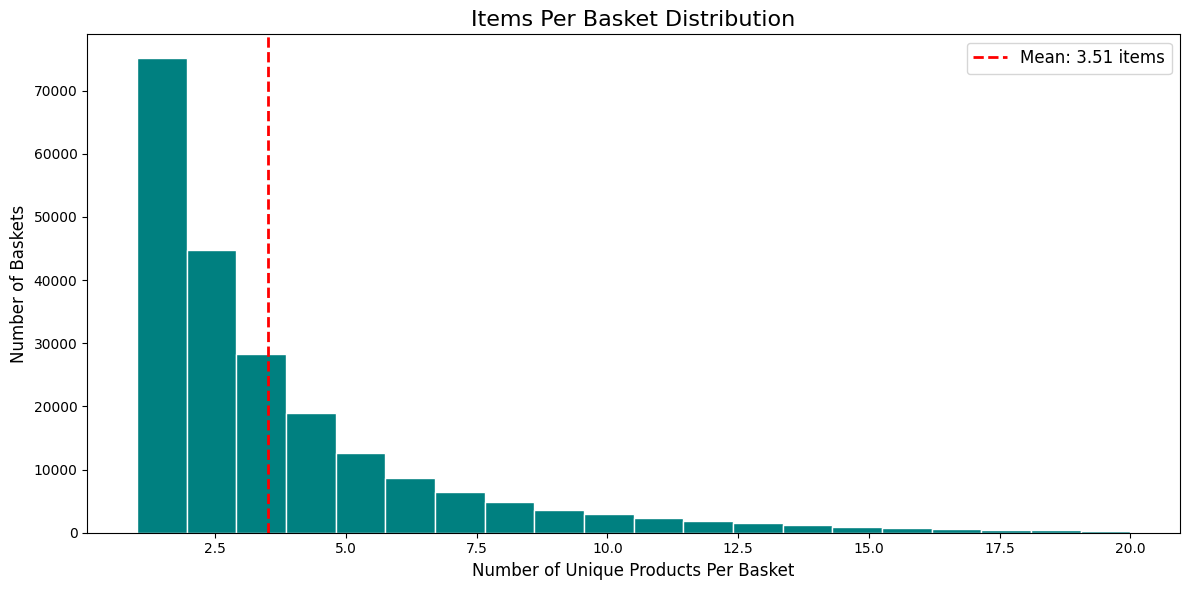

Chart 5 saved!
Mean items per basket: 3.51
Single item baskets: 75,168


In [12]:
items_per_basket = df.groupby('invoice_no')['product'].nunique()

plt.figure(figsize=(12, 6))
plt.hist(items_per_basket[items_per_basket <= 20], bins=20, color='teal', edgecolor='white')
plt.axvline(items_per_basket.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {items_per_basket.mean():.2f} items')
plt.title('Items Per Basket Distribution', fontsize=16)
plt.xlabel('Number of Unique Products Per Basket', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart5_items_per_basket.png'), dpi=150)
plt.show()
print(f"Chart 5 saved!")
print(f"Mean items per basket: {items_per_basket.mean():.2f}")
print(f"Single item baskets: {(items_per_basket == 1).sum():,}")

## Chart 6: Categories Per Basket

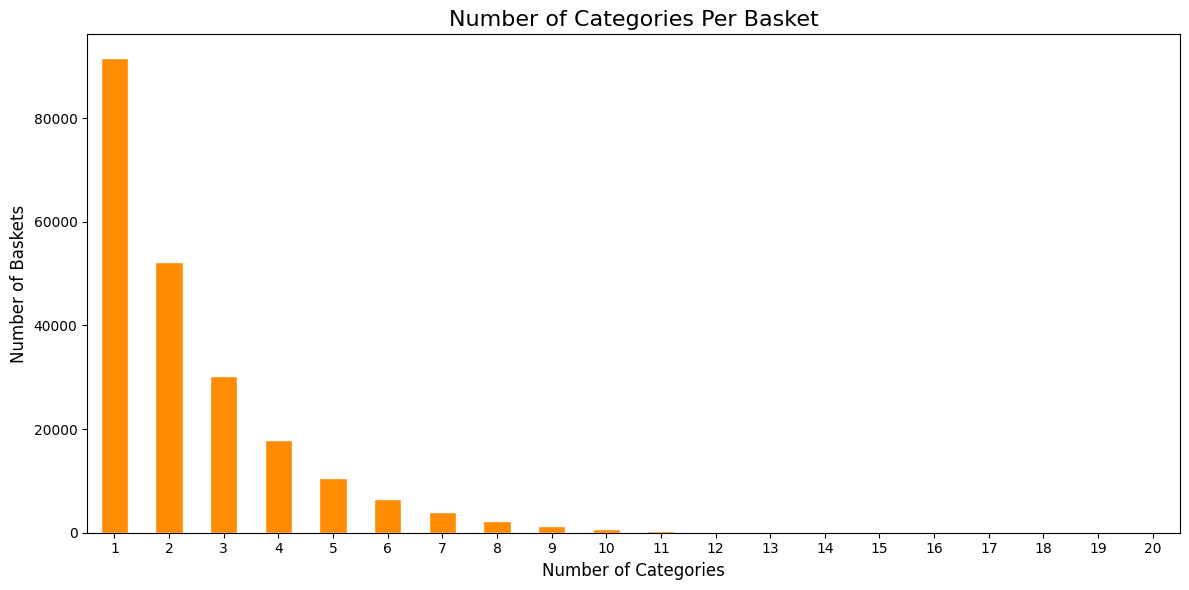

Chart 6 saved!
Mean categories per basket: 2.40
Baskets with only 1 category: 91,607
Baskets with 3+ categories: 74,160


In [13]:
categories_per_basket = df.groupby('invoice_no')['category'].nunique()

plt.figure(figsize=(12, 6))
categories_per_basket.value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Number of Categories Per Basket', fontsize=16)
plt.xlabel('Number of Categories', fontsize=12)
plt.ylabel('Number of Baskets', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart6_categories_per_basket.png'), dpi=150)
plt.show()
print("Chart 6 saved!")
print(f"Mean categories per basket: {categories_per_basket.mean():.2f}")
print(f"Baskets with only 1 category: {(categories_per_basket == 1).sum():,}")
print(f"Baskets with 3+ categories: {(categories_per_basket >= 3).sum():,}")

## Chart 7: Category Co-occurrence Heatmap

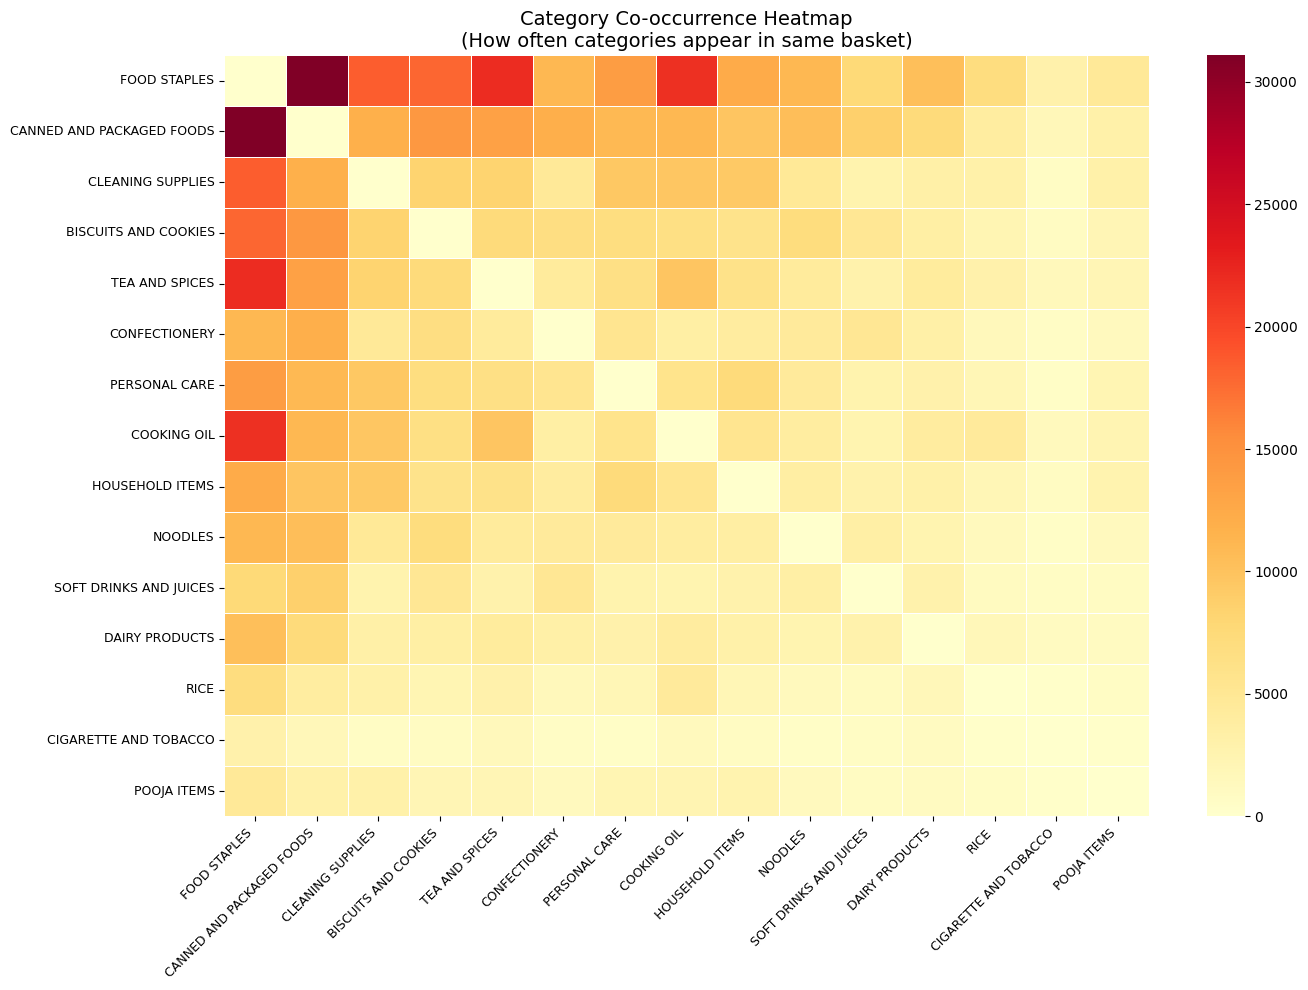

Chart 7 saved!


In [14]:
from itertools import combinations

basket_categories = df.groupby('invoice_no')['category'].apply(set)

co_occur = {}
for basket in basket_categories:
    for cat1, cat2 in combinations(sorted(basket), 2):
        pair = (cat1, cat2)
        co_occur[pair] = co_occur.get(pair, 0) + 1

top_categories = df['category'].value_counts().head(15).index.tolist()

matrix = pd.DataFrame(0, index=top_categories, columns=top_categories)

for (cat1, cat2), count in co_occur.items():
    if cat1 in top_categories and cat2 in top_categories:
        matrix.loc[cat1, cat2] = count
        matrix.loc[cat2, cat1] = count

plt.figure(figsize=(14, 10))
sns.heatmap(matrix, annot=False, cmap='YlOrRd', linewidths=0.5)
plt.title('Category Co-occurrence Heatmap\n(How often categories appear in same basket)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart7_category_cooccurrence_heatmap.png'), dpi=150)
plt.show()
print("Chart 7 saved!")

## Chart 8: Top Product Pairs Bought Together

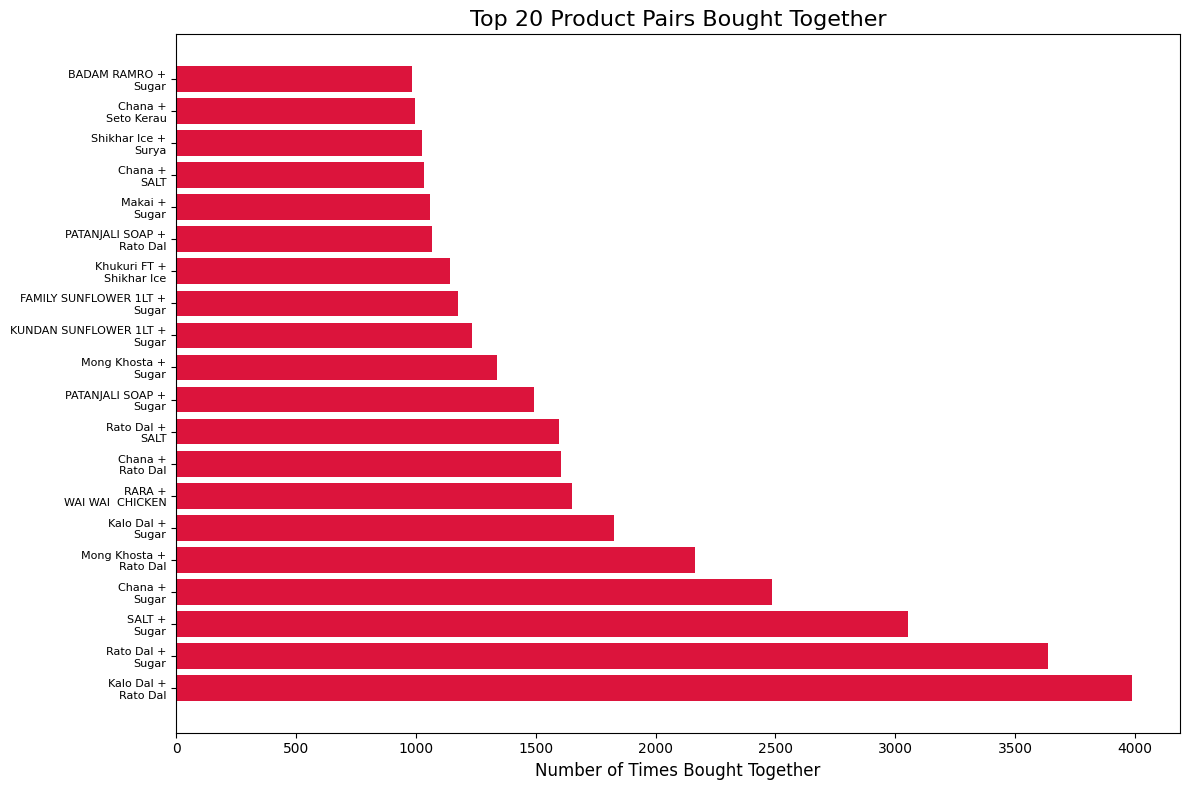

Chart 8 saved!

Top 10 product pairs:
           product_1         product_2  count
93          Kalo Dal          Rato Dal   3989
109         Rato Dal             Sugar   3639
1905            SALT             Sugar   3055
400            Chana             Sugar   2485
1722     Mong Khosta          Rato Dal   2164
106         Kalo Dal             Sugar   1825
926             RARA  WAI WAI  CHICKEN   1653
1581           Chana          Rato Dal   1605
2338        Rato Dal              SALT   1596
1277  PATANJALI SOAP             Sugar   1494


In [15]:
from itertools import combinations

basket_products = df.groupby('invoice_no')['product'].apply(set)

product_pairs = {}
for basket in basket_products:
    if len(basket) >= 2:
        for prod1, prod2 in combinations(sorted(basket), 2):
            pair = (prod1, prod2)
            product_pairs[pair] = product_pairs.get(pair, 0) + 1

pairs_df = pd.DataFrame([
    {'product_1': p1, 'product_2': p2, 'count': count}
    for (p1, p2), count in product_pairs.items()
]).sort_values('count', ascending=False).head(20)

plt.figure(figsize=(12, 8))
pair_labels = [f"{row['product_1'][:20]} +\n{row['product_2'][:20]}" 
               for _, row in pairs_df.iterrows()]
plt.barh(range(len(pairs_df)), pairs_df['count'], color='crimson')
plt.yticks(range(len(pairs_df)), pair_labels, fontsize=8)
plt.title('Top 20 Product Pairs Bought Together', fontsize=16)
plt.xlabel('Number of Times Bought Together', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart8_top_product_pairs.png'), dpi=150)
plt.show()
print("Chart 8 saved!")
print("\nTop 10 product pairs:")
print(pairs_df[['product_1', 'product_2', 'count']].head(10).to_string())

In [16]:
import os

figures = os.listdir(figures_path)
print(f"Charts saved: {len(figures)}")
for f in sorted(figures):
    print(f"  {f}")

Charts saved: 8
  chart1_top20_products_count.png
  chart2_category_distribution.png
  chart3_top20_products_revenue.png
  chart4_basket_value_distribution.png
  chart5_items_per_basket.png
  chart6_categories_per_basket.png
  chart7_category_cooccurrence_heatmap.png
  chart8_top_product_pairs.png


## EDA Complete!

### Key Findings:

1. Sugar is the most frequently paired product across the store
2. FOOD STAPLES is the largest category at 23% of all transactions
3. Average basket value is Rs 1,001.59 - this is our primary KPI baseline
4. Most customers buy 1 to 5 products per trip
5. Kalo Dal and Rato Dal are bought together 4,000 times - strongest pair
6. Dal products, Sugar and Salt are consistently bought together
7. WAI WAI CHICKEN and RARA noodles are frequently paired
8. These patterns directly inform our shelf placement recommendations

### Next Step: 04_transaction_encoding.ipynb